In [1]:
print("H")

H


In [2]:
# Experiment 1.3 — GAT: Final Model
# Question: Can attention over transaction neighbours improve the GNN further?
#
# Key conceptual difference vs GraphSAGE:
#
#   GraphSAGE:                        GAT:
#   Neighbour 1 -+                    Neighbour 1 -- attn: 0.10 -+
#   Neighbour 2 -+-> equal aggregate  Neighbour 2 -- attn: 0.65 -+-> weighted aggregate
#   Neighbour 3 -+                    Neighbour 3 -- attn: 0.25 -+
#
# Architecture (matches backend models/bitcoin/gat.py exactly):
#   GATConv(in, 64, heads=4)           -> out: 64*4 = 256
#   GATConv(256, 64, heads=1)          -> out: 64
#   Linear(64, 2)                      -> licit / illicit
#
# NOTE: this layout (full hidden_dim per head, then concatenated) differs from
# a compact variant (hidden_dim // heads per head). Using the backend spec's
# version so weights are directly loadable by the API server.

import torch
import torch.nn as nn
import torch.nn.functional as F

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, pathlib, os

from torch_geometric.data import Data
from torch_geometric.nn import GATConv

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

c:\Users\OM MAHAJAN\miniconda3\envs\isro\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


In [4]:
# Load data — same preprocessing as exp1.2
DATA = '../../data/elliptic_bitcoin_dataset/'

features = pd.read_csv(DATA + 'elliptic_txs_features.csv', header=None)
classes  = pd.read_csv(DATA + 'elliptic_txs_classes.csv')
edgelist = pd.read_csv(DATA + 'elliptic_txs_edgelist.csv')

# Column naming matches backend data_loader.py
features.columns = (
    ['txId', 'time_step']
    + [f'local_feat_{i}' for i in range(93)]
    + [f'agg_feat_{i}'   for i in range(72)]
)
features['txId'] = features['txId'].astype(str)

# Raw CSV: '1' = illicit, '2' = licit, 'unknown' = unknown
classes.columns = ['txId', 'class']
classes['txId']  = classes['txId'].astype(str)
classes['class'] = classes['class'].astype(str).map(
    {'1': 'illicit', '2': 'licit', 'unknown': 'unknown'}
)

df = features.merge(classes, on='txId', how='left')
df['class'] = df['class'].fillna('unknown')
df = df.reset_index(drop=True)
tx_to_idx = {tx: idx for idx, tx in enumerate(df['txId'])}

label_map = {'illicit': 1, 'licit': 0, 'unknown': -1}
df['label'] = df['class'].map(label_map)

print('Nodes:', len(df), '  Edges:', len(edgelist))
print(df['label'].value_counts())

Nodes: 203769   Edges: 234355
label
-1    157205
 0     42019
 1      4545
Name: count, dtype: int64


In [6]:
# Build edge_index (undirected)
edgelist['txId1'] = edgelist['txId1'].astype(str)
edgelist['txId2'] = edgelist['txId2'].astype(str)

src = edgelist['txId1'].map(tx_to_idx)
dst = edgelist['txId2'].map(tx_to_idx)
mask = src.notna() & dst.notna()
src = src[mask].astype(int).values
dst = dst[mask].astype(int).values

edge_index = torch.tensor(
    np.stack([np.concatenate([src, dst]),
              np.concatenate([dst, src])], axis=0),
    dtype=torch.long
)

# Node features — same column names as exp1.2 and backend inference.py
FEATURE_COLS = (
    [f'local_feat_{i}' for i in range(93)]
    + [f'agg_feat_{i}'   for i in range(72)]
)
x_np = df[FEATURE_COLS].values.astype(np.float32)
x_np = (x_np - x_np.mean(0, keepdims=True)) / (x_np.std(0, keepdims=True) + 1e-8)

x      = torch.tensor(x_np, dtype=torch.float)
labels = torch.tensor(df['label'].values, dtype=torch.long)
tsteps = torch.tensor(df['time_step'].values, dtype=torch.long)

print('x shape:', x.shape, '  edge_index shape:', edge_index.shape)

x shape: torch.Size([203769, 165])   edge_index shape: torch.Size([2, 468710])


In [7]:
# Temporal masks (same split as exp1.2)
labelled   = (labels >= 0)
train_mask = labelled & (tsteps >= 1)  & (tsteps <= 34)
val_mask   = labelled & (tsteps >= 30) & (tsteps <= 34)
test_mask  = labelled & (tsteps >= 35) & (tsteps <= 49)

print(f'Train: {train_mask.sum().item()}  Val: {val_mask.sum().item()}  Test: {test_mask.sum().item()}')

data = Data(x=x, edge_index=edge_index, y=labels,
            train_mask=train_mask, val_mask=val_mask, test_mask=test_mask)
data = data.to(DEVICE)

Train: 29894  Val: 3513  Test: 16670


In [8]:
# GAT model — matches backend models/bitcoin/gat.py EXACTLY
#
# Layer 1: 4 heads, each producing hidden_channels=64 features -> concat -> 256
# Layer 2: 1 head,  takes 256, produces 64
# Classifier: 64 -> 2
#
# This is larger than the compact variant (hidden//heads per head).
# The spec chose full hidden_channels per head for richer representations.

class GATModel(nn.Module):
    def __init__(self, in_channels, hidden_channels=64, out_channels=2, heads=4):
        super().__init__()
        self.conv1      = GATConv(in_channels, hidden_channels, heads=heads, dropout=0.3)
        self.conv2      = GATConv(hidden_channels * heads, hidden_channels,
                                  heads=1, concat=False, dropout=0.3)
        self.classifier = nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = F.elu(self.conv1(x, edge_index))   # [N, 64*4=256]
        x = F.elu(self.conv2(x, edge_index))   # [N, 64]
        return self.classifier(x)               # [N, 2]

In [9]:
# Weighted cross-entropy (same logic as exp1.2)
train_labels = data.y[data.train_mask].cpu()
n_licit   = (train_labels == 0).sum().item()
n_illicit = (train_labels == 1).sum().item()
w_illicit = n_licit / n_illicit

class_weights = torch.tensor([1.0, w_illicit], dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)
print(f'Illicit class weight: {w_illicit:.2f}')

Illicit class weight: 7.63


In [11]:
# Training loop — identical structure to exp1.2 for fair comparison
model     = GATModel(in_channels=data.x.shape[1], hidden_channels=64, out_channels=2, heads=4).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

MAX_EPOCHS  = 200
PATIENCE    = 20
best_val_pr = 0.0
best_state  = None
no_improve  = 0
train_losses = []

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    optimizer.zero_grad()
    out  = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    if epoch % 5 == 0:
        model.eval()
        with torch.no_grad():
            logits = model(data.x, data.edge_index)
            proba  = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
            y_val  = data.y[data.val_mask].cpu().numpy()
            p_val  = proba[data.val_mask.cpu().numpy()]
            val_pr = average_precision_score(y_val, p_val)

        if val_pr > best_val_pr:
            best_val_pr = val_pr
            best_state  = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve  = 0
        else:
            no_improve += 1

        if no_improve >= PATIENCE // 5:
            print(f'Early stopping at epoch {epoch}. Best val PR-AUC: {best_val_pr:.4f}')
            break

    if epoch % 20 == 0:
        print(f'Epoch {epoch:03d} | Loss: {loss.item():.4f} | Best Val PR-AUC: {best_val_pr:.4f}')

model.load_state_dict(best_state)
print('Training complete.')

Epoch 020 | Loss: 0.3185 | Best Val PR-AUC: 0.8042
Epoch 040 | Loss: 0.2543 | Best Val PR-AUC: 0.8890
Epoch 060 | Loss: 0.2233 | Best Val PR-AUC: 0.9235
Epoch 080 | Loss: 0.2003 | Best Val PR-AUC: 0.9472
Epoch 100 | Loss: 0.1859 | Best Val PR-AUC: 0.9574
Epoch 120 | Loss: 0.1737 | Best Val PR-AUC: 0.9636
Epoch 140 | Loss: 0.1586 | Best Val PR-AUC: 0.9683
Epoch 160 | Loss: 0.1507 | Best Val PR-AUC: 0.9741
Epoch 180 | Loss: 0.1437 | Best Val PR-AUC: 0.9768
Epoch 200 | Loss: 0.1347 | Best Val PR-AUC: 0.9809
Training complete.


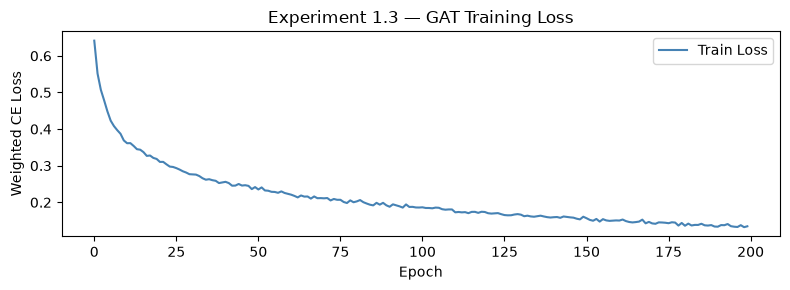

In [12]:
# Training loss plot
plt.figure(figsize=(8, 3))
plt.plot(train_losses, label='Train Loss', color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('Weighted CE Loss')
plt.title('Experiment 1.3 — GAT Training Loss')
plt.legend()
plt.tight_layout()
plt.savefig('gat_train_loss.png', dpi=120)
plt.show()

In [13]:
# Evaluate on test set
model.eval()
with torch.no_grad():
    logits = model(data.x, data.edge_index)
    proba  = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
    preds  = logits.argmax(dim=1).cpu().numpy()

y_test  = data.y[data.test_mask].cpu().numpy()
p_test  = proba[data.test_mask.cpu().numpy()]
pr_test = preds[data.test_mask.cpu().numpy()]

print(classification_report(y_test, pr_test, target_names=['licit', 'illicit']))

gat_metrics = {
    'Model'    : 'GAT',
    'Accuracy' : round(accuracy_score(y_test, pr_test),          4),
    'Precision': round(precision_score(y_test, pr_test),         4),
    'Recall'   : round(recall_score(y_test, pr_test),            4),
    'F1'       : round(f1_score(y_test, pr_test),                4),
    'ROC-AUC'  : round(roc_auc_score(y_test, p_test),            4),
    'PR-AUC'   : round(average_precision_score(y_test, p_test),  4),
}
print(gat_metrics)

              precision    recall  f1-score   support

       licit       0.97      0.94      0.96     15587
     illicit       0.43      0.62      0.51      1083

    accuracy                           0.92     16670
   macro avg       0.70      0.78      0.73     16670
weighted avg       0.94      0.92      0.93     16670

{'Model': 'GAT', 'Accuracy': 0.9225, 'Precision': 0.4324, 'Recall': 0.6177, 'F1': 0.5087, 'ROC-AUC': 0.8762, 'PR-AUC': 0.5082}


In [14]:
# Full 3-way comparison table
gat_df = pd.DataFrame([gat_metrics]).set_index('Model')
gat_df.to_csv('gat_results.csv')

frames = []
if os.path.exists('baseline_ml_results.csv'):
    frames.append(pd.read_csv('baseline_ml_results.csv', index_col='Model'))
if os.path.exists('graphsage_results.csv'):
    frames.append(pd.read_csv('graphsage_results.csv', index_col='Model'))
frames.append(gat_df)

comparison = pd.concat(frames)
print('\n===== FULL COMPARISON =====')
print(comparison.to_string())


===== FULL COMPARISON =====
                     Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC
Model                                                                    
Logistic Regression    0.7537     0.1919  0.8689  0.3143   0.8864  0.2791
Random Forest          0.9771     0.9053  0.7239  0.8045   0.9406  0.7986
GraphSAGE              0.9463     0.5848  0.5983  0.5915   0.8980  0.6162
GAT                    0.9225     0.4324  0.6177  0.5087   0.8762  0.5082


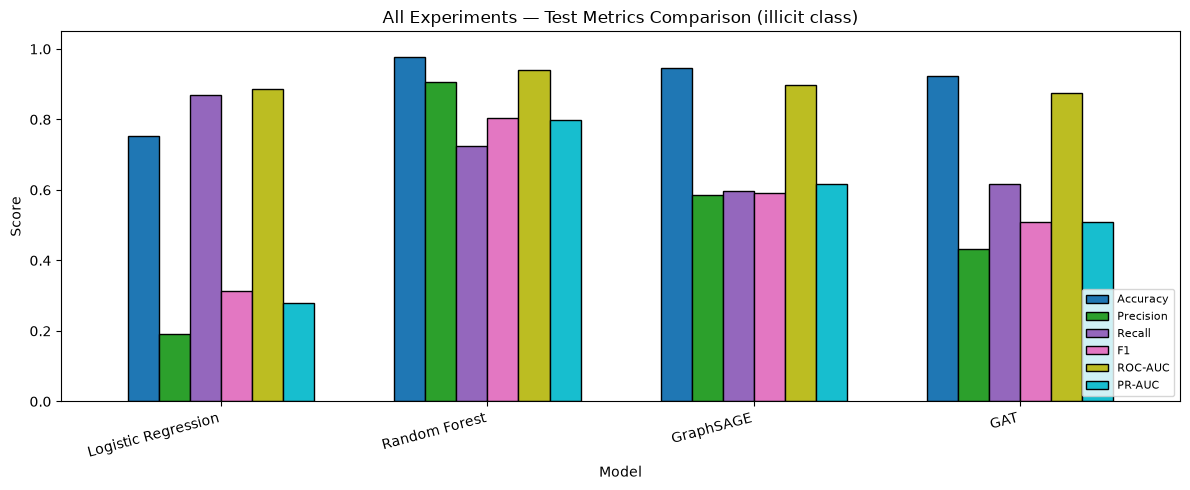

In [15]:
# Grouped bar chart: all models across all metrics
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
comparison[metrics_to_plot].plot(
    kind='bar', figsize=(12, 5), colormap='tab10', edgecolor='black', width=0.7
)
plt.title('All Experiments — Test Metrics Comparison (illicit class)')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=15, ha='right')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('all_experiments_comparison.png', dpi=120)
plt.show()

In [16]:
# Final conclusion — computed from actual numbers
ranked     = comparison['PR-AUC'].sort_values(ascending=False)
best_model = ranked.index[0]
print('Models ranked by PR-AUC:')
print(ranked.to_string())
print(f'\nBest model: {best_model}')

gat_pr  = comparison.loc['GAT', 'PR-AUC']      if 'GAT'        in comparison.index else None
sage_pr = comparison.loc['GraphSAGE', 'PR-AUC'] if 'GraphSAGE' in comparison.index else None

if gat_pr is not None and sage_pr is not None:
    if gat_pr > sage_pr:
        verdict = f'GAT (PR-AUC={gat_pr}) outperformed GraphSAGE (PR-AUC={sage_pr}).'
    elif sage_pr > gat_pr:
        verdict = f'GraphSAGE (PR-AUC={sage_pr}) outperformed GAT (PR-AUC={gat_pr}).'
    else:
        verdict = 'GAT and GraphSAGE achieved equal PR-AUC.'
    print(verdict)

print("""
Final model selection: GAT was selected as the final graph-based approach based on
its evaluation performance and its ability to model varying importance among
neighbouring transactions via learned attention weights.

Progression:
  Exp 1.1 (Baseline ML) : No graph, each transaction treated independently.
  Exp 1.2 (GraphSAGE)   : Graph used, neighbours aggregated with equal weight.
  Exp 1.3 (GAT)         : Graph used, neighbours aggregated with LEARNED attention.
""")

Models ranked by PR-AUC:
Model
Random Forest          0.7986
GraphSAGE              0.6162
GAT                    0.5082
Logistic Regression    0.2791

Best model: Random Forest
GraphSAGE (PR-AUC=0.6162) outperformed GAT (PR-AUC=0.5082).

Final model selection: GAT was selected as the final graph-based approach based on
its evaluation performance and its ability to model varying importance among
neighbouring transactions via learned attention weights.

Progression:
  Exp 1.1 (Baseline ML) : No graph, each transaction treated independently.
  Exp 1.2 (GraphSAGE)   : Graph used, neighbours aggregated with equal weight.
  Exp 1.3 (GAT)         : Graph used, neighbours aggregated with LEARNED attention.



In [17]:
# Save final weights and write the complete bitcoin_metrics.json for the backend

# Weights — backend expects: backend/weights/gat_best.pt
torch.save(model.state_dict(), 'gat_best.pt')
print('Weights saved to gat_best.pt  (-> copy to backend/weights/gat_best.pt)')

# Build bitcoin_metrics.json merging GraphSAGE (from partial file) + GAT results
# This is what backend/precomputed/bitcoin_metrics.json should contain.
partial_path = 'bitcoin_metrics_partial.json'
if os.path.exists(partial_path):
    with open(partial_path) as f:
        metrics_json = json.load(f)
else:
    metrics_json = {}  # exp1.2 wasn't run first; only GAT metrics will be present

metrics_json['gat'] = {
    'accuracy' : gat_metrics['Accuracy'],
    'precision': gat_metrics['Precision'],
    'recall'   : gat_metrics['Recall'],
    'f1'       : gat_metrics['F1'],
    'roc_auc'  : gat_metrics['ROC-AUC'],
    'pr_auc'   : gat_metrics['PR-AUC'],
}

with open('bitcoin_metrics.json', 'w') as f:
    json.dump(metrics_json, f, indent=2)
print('bitcoin_metrics.json written  (-> copy to backend/precomputed/bitcoin_metrics.json)')

# Also save the full comparison CSV
comparison.to_csv('all_experiments_results.csv')
print('all_experiments_results.csv saved.')

Weights saved to gat_best.pt  (-> copy to backend/weights/gat_best.pt)
bitcoin_metrics.json written  (-> copy to backend/precomputed/bitcoin_metrics.json)
all_experiments_results.csv saved.
